In [10]:
# Artificial Equilibrium
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

In [11]:
# Parameters
mu   = 3.00348e-6
beta = 0.01

C, A, m_s  = 4.57e-6, 3244.0, 500.0
G_Ms, AU_m = 1.327124e20, 1.496e11
beta_check = (2*C*A/m_s) / (G_Ms/AU_m**2)

In [12]:
# Classical L1 and L2
def collinear(x):
    r1 = abs(x + mu);  r2 = abs(x - 1 + mu)
    return x - (1-mu)*(x+mu)/r1**3 - mu*(x-1+mu)/r2**3

L1x = fsolve(collinear, 0.99)[0]
L2x = fsolve(collinear, 1.01)[0]

In [13]:
# Equilibrium residual 
def residual(state, alpha, delta, b):
    X, Y, Z = float(state[0]), float(state[1]), float(state[2])
    r1 = max(np.sqrt((X+mu)**2   + Y**2 + Z**2), 1e-14)
    r2 = max(np.sqrt((X-1+mu)**2 + Y**2 + Z**2), 1e-14)
    phi = np.arctan2(Y, X+mu)
    psi = np.arctan2(Z, np.sqrt((X+mu)**2 + Y**2))
    Nx  = np.cos(phi+alpha) * np.cos(psi+delta)
    Ny  = np.sin(phi+alpha) * np.cos(psi+delta)
    Nz  = np.sin(psi+delta)
    ur  = np.array([X+mu, Y, Z]) / r1
    ct  = max(float(np.dot(ur, [Nx, Ny, Nz])), 0.0)
    sf  = b * (1-mu) / r1**2 * ct**2
    return [
        X - (1-mu)*(X+mu)/r1**3 - mu*(X-1+mu)/r2**3 + sf*Nx,
        Y - (1-mu)*Y/r1**3      - mu*Y/r2**3          + sf*Ny,
          - (1-mu)*Z/r1**3      - mu*Z/r2**3           + sf*Nz
    ]

In [14]:
# Solving full 2D grid at beta=0.01
N = 60
alpha_arr = np.linspace(-np.pi/2, np.pi/2, N)
delta_arr = np.linspace(-np.pi/2, np.pi/2, N)

X_grid = np.full((N, N), np.nan)
Y_grid = np.full((N, N), np.nan)
Z_grid = np.full((N, N), np.nan)

In [15]:
# Solving full grid at beta=0.01 ...
for i, alpha in enumerate(alpha_arr):
    for j, delta in enumerate(delta_arr):
        for x0 in ([L2x, 0, 0], [L1x, 0, 0]):
            sol, info, flag, _ = fsolve(residual, x0,
                                        args=(alpha, delta, beta),
                                        full_output=True, xtol=1e-13)
            if flag == 1 and np.linalg.norm(info['fvec']) < 1e-10:
                X_grid[i, j] = sol[0]
                Y_grid[i, j] = sol[1]
                Z_grid[i, j] = sol[2]
                break


In [16]:
# Coordinates for meera
eq0 = fsolve(residual, [L2x, 0, 0], args=(0.0, 0.0, beta))
print("COORDINATES")
print(f"  alpha = 0,  delta = 0  (sail perpendicular to Sun)")
print(f"  X0 = {eq0[0]:.10f} AU")
print(f"  Y0 = {eq0[1]:.10f} AU")
print(f"  Z0 = {eq0[2]:.10f} AU")


COORDINATES
  alpha = 0,  delta = 0  (sail perpendicular to Sun)
  X0 = 1.0090418181 AU
  Y0 = 0.0000000000 AU
  Z0 = 0.0000000000 AU


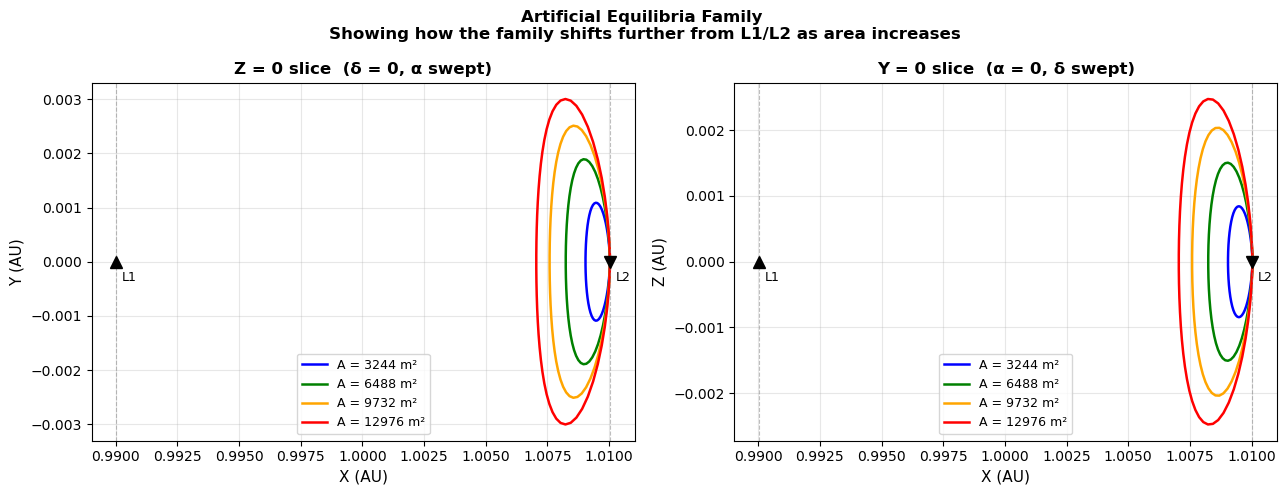

In [17]:
# Figure 1 Multi-area
areas_plot  = [3244, 6488, 9732, 12976]   # sail areas in m²
colors_plot = ['blue', 'green', 'orange', 'red']

# Ensure sweep arrays are defined (in case cell order differs)
N = 60
alpha_arr = np.linspace(-np.pi/2, np.pi/2, N)
delta_arr = np.linspace(-np.pi/2, np.pi/2, N)

# Conversion: area (m²) -> dimensionless beta lightness number
def area_to_beta(A_val):
    return (2 * C * A_val / m_s) / (G_Ms / AU_m**2)

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig1.suptitle("Artificial Equilibria Family \n"
              "Showing how the family shifts further from L1/L2 as area increases",
              fontsize=12, fontweight='bold')

for A_val, col in zip(areas_plot, colors_plot):
    b = area_to_beta(A_val)   # convert area to beta before passing to residual
    # Z=0 slice: fix delta=0, sweep alpha
    Xz, Yz = [], []
    for alpha in alpha_arr:
        sol, info, flag, _ = fsolve(residual, [L2x, 0, 0],
                                    args=(alpha, 0.0, b),
                                    full_output=True, xtol=1e-13)
        if flag == 1 and np.linalg.norm(info['fvec']) < 1e-10:
            Xz.append(sol[0]); Yz.append(sol[1])

    # Y=0 slice: fix alpha=0, sweep delta
    Xy, Zy = [], []
    for delta in delta_arr:
        sol, info, flag, _ = fsolve(residual, [L2x, 0, 0],
                                    args=(0.0, delta, b),
                                    full_output=True, xtol=1e-13)
        if flag == 1 and np.linalg.norm(info['fvec']) < 1e-10:
            Xy.append(sol[0]); Zy.append(sol[2])

    ax1.plot(Xz, Yz, color=col, linewidth=1.8, label=f'A = {A_val} m²')
    ax2.plot(Xy, Zy, color=col, linewidth=1.8, label=f'A = {A_val} m²')

for ax in (ax1, ax2):
    ax.axvline(L1x, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(L2x, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.plot(L1x, 0, 'k^', ms=9, zorder=5)
    ax.plot(L2x, 0, 'kv', ms=9, zorder=5)
    ax.annotate('L1', (L1x, 0), xytext=(4, -14),
                textcoords='offset points', fontsize=9)
    ax.annotate('L2', (L2x, 0), xytext=(4, -14),
                textcoords='offset points', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

ax1.set_xlabel('X (AU)', fontsize=11); ax1.set_ylabel('Y (AU)', fontsize=11)
ax1.set_title('Z = 0 slice  (δ = 0, α swept)', fontweight='bold')
ax2.set_xlabel('X (AU)', fontsize=11); ax2.set_ylabel('Z (AU)', fontsize=11)
ax2.set_title('Y = 0 slice  (α = 0, δ swept)', fontweight='bold')
fig1.tight_layout()

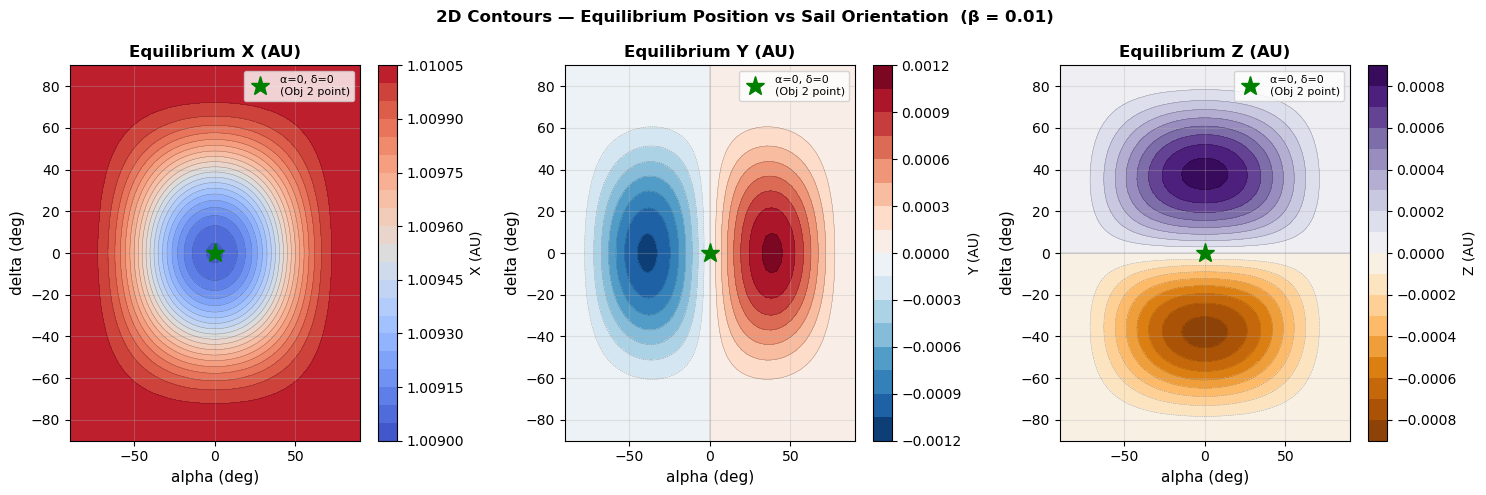

In [18]:
# Figure 2; 2D contours at beta=0.01 
Ad, Dd = np.meshgrid(np.degrees(alpha_arr),
                     np.degrees(delta_arr), indexing='ij')

fig2, axes = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle(f"2D Contours — Equilibrium Position vs Sail Orientation  (β = {beta})",
              fontsize=12, fontweight='bold')

grids  = [X_grid,     Y_grid,    Z_grid  ]
titles = ['X (AU)',   'Y (AU)',  'Z (AU)']
cmaps  = ['coolwarm', 'RdBu_r', 'PuOr'  ]

for ax, grid, title, cmap in zip(axes, grids, titles, cmaps):
    cf = ax.contourf(Ad, Dd, grid, levels=20, cmap=cmap)
    ax.contour(Ad, Dd, grid, levels=20, colors='k', linewidths=0.3, alpha=0.4)
    plt.colorbar(cf, ax=ax, label=title)
    ax.plot(0, 0, 'g*', ms=14, zorder=5, label='α=0, δ=0\n(Obj 2 point)')
    ax.set_xlabel('alpha (deg)', fontsize=11)
    ax.set_ylabel('delta (deg)', fontsize=11)
    ax.set_title(f'Equilibrium {title}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig2.tight_layout()
plt.show()